# Required Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import pandas as pd
import numpy as np


from scipy.ndimage import shift
from scipy.stats import qmc
from joblib import Parallel, delayed


# Input files and user-defined parametres

In [ ]:
# Load input data
true_mask = np.loadtxt("/content/debris_flow_bounds_c.csv", delimiter=",")
thickness_file = "/content/depth15m_chooralmala_new.csv"
dem_file = "/content/dem_chooralmala_new.csv"
e_bed_file = "/content/newgully10m.csv"
dx, dy = 12.49, 12.49  # Grid resolution (m)
hfluxmin = 0.01  # Threshold for binarizing h
g = 9.81
CFLcond = 0.8
dtmin = 0.05
max_steps = 3000
stop_threshold = 1
maxthick = 50

# Initialise variables

In [ ]:
# Load initial data
h = np.asarray(np.loadtxt(thickness_file, delimiter=","))
z = np.asarray(np.loadtxt(dem_file, delimiter=","))
e_bed = np.asarray(np.loadtxt(e_bed_file, delimiter=","))
nrow, ncol = h.shape

In [ ]:
# Diagnostic: Check initial conditions
print(f"Initial h: min={np.min(h):.4f}, max={np.max(h):.4f}, mean={np.mean(h):.4f}")
print(f"Initial z: min={np.min(z):.4f}, max={np.max(z):.4f}, mean={np.mean(z):.4f}")
print(f"Initial slopexz: max={np.max(np.abs(np.arctan((z[:, 1:] - z[:, :-1]) / dx))):.4f} rad")
print(f"Initial slopeyz: max={np.max(np.abs(np.arctan((z[1:, :] - z[:-1, :]) / dy))):.4f} rad")

Initial h: min=0.0000, max=15.0000, mean=0.0197
Initial z: min=0.0000, max=2042.0000, mean=521.9238
Initial slopexz: max=1.5647 rad
Initial slopeyz: max=1.5647 rad


In [ ]:
# Define plotting setup (global for visualization)
fig, ax = plt.subplots(figsize=(7, 7))
img = ax.imshow(h, cmap='viridis', origin='lower', vmin=0, vmax=30)
plt.colorbar(img, ax=ax, label='Thickness (m)')
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
plt.close(fig)
last_output_time = [-1.0]

# Processing slopes and curvature of dem (only t == 0)

In [ ]:
# Helper functions (defined first to avoid "function not defined")
def compute_interface_slope_features(z, dx, dy):
    dirxz = np.zeros((nrow, ncol - 1))
    diryz = np.zeros((nrow - 1, ncol))
    slopexz = np.zeros((nrow, ncol - 1))
    slopeyz = np.zeros((nrow - 1, ncol))

    A = (z[2:nrow, 0:ncol-1] + z[2:nrow, 1:ncol]) / 2.0
    B = (z[0:nrow-2, 0:ncol-1] + z[0:nrow-2, 1:ncol]) / 2.0
    term1 = (A - B) / (2 * dy)
    term2 = (z[1:nrow-1, 1:ncol] - z[1:nrow-1, 0:ncol-1]) / dx
    dirxz[1:nrow-1, :] = np.pi/2 - np.arctan2(term1, term2)
    slopexz[1:nrow-1, :] = np.arctan(np.sqrt(term1**2 + term2**2))

    term1 = (z[1:nrow, 1:ncol-1] - z[0:nrow-1, 1:ncol-1]) / dy
    A = (z[0:nrow-1, 2:ncol] + z[1:nrow, 2:ncol]) / 2.0
    B = (z[0:nrow-1, 0:ncol-2] + z[1:nrow, 0:ncol-2]) / 2.0
    term2 = (A - B) / (2 * dx)
    diryz[:, 1:ncol-1] = np.pi/2 - np.arctan2(term1, term2)
    slopeyz[:, 1:ncol-1] = np.arctan(np.sqrt(term1**2 + term2**2))

    return dirxz, diryz, slopexz, slopeyz

def correct_cell_edge_features(z, dx, dy):
    dx_x = np.full((nrow, ncol - 1), dx)
    dy_x = np.full((nrow, ncol - 1), dy)
    dy_y = np.full((nrow - 1, ncol), dy)
    dx_y = np.full((nrow - 1, ncol), dx)
    S = np.full((nrow, ncol), dx * dy)

    dy_x[1:nrow-1, :] = np.sqrt(
        ((z[2:nrow, 0:ncol-1] + z[2:nrow, 1:ncol]) / 2.0 -
         (z[0:nrow-2, 0:ncol-1] + z[0:nrow-2, 1:ncol]) / 2.0)**2 + (2 * dy)**2
    ) / 2.0

    dx_y[:, 1:ncol-1] = np.sqrt(
        ((z[0:nrow-1, 2:ncol] + z[1:nrow, 2:ncol]) / 2.0 -
         (z[0:nrow-1, 0:ncol-2] + z[1:nrow, 0:ncol-2]) / 2.0)**2 + (2 * dx)**2
    ) / 2.0

    dx_x[:, :] = np.sqrt((z[:, 1:ncol] - z[:, 0:ncol-1])**2 + dx**2)
    dy_y[:, :] = np.sqrt((z[1:nrow, :] - z[0:nrow-1, :])**2 + dy**2)

    S[1:nrow-1, 1:ncol-1] = (
        (dx_x[1:nrow-1, 0:ncol-2] / 2.0 + dx_x[1:nrow-1, 1:ncol-1] / 2.0) *
        (dy_y[1:nrow-1, 1:ncol-1] / 2.0 + dy_y[0:nrow-2, 1:ncol-1] / 2.0)
    )
    S[0, :] = S[1, :]
    S[nrow-1, :] = S[nrow-2, :]
    S[:, 0] = S[:, 1]
    S[:, ncol-1] = S[:, ncol-2]

    return dx_x, dy_x, dy_y, dx_y, S

def compute_slope_curvature(z, dx, dy, dx_x, dy_y):
    Cx = np.zeros_like(z)
    Cx[:, 1:ncol-1] = (z[:, 0:ncol-2] + z[:, 2:ncol] - 2 * z[:, 1:ncol-1]) / (dx**2)
    Cx[:, 1:ncol-1] /= (1 + ((z[:, 2:ncol] - z[:, 0:ncol-2]) / (2 * dx))**2) ** 1.5

    Cy = np.zeros_like(z)
    Cy[1:nrow-1, :] = (z[0:nrow-2, :] + z[2:nrow, :] - 2 * z[1:nrow-1, :]) / (dy**2)
    Cy[1:nrow-1, :] /= (1 + ((z[2:nrow, :] - z[0:nrow-2, :]) / (2 * dy))**2) ** 1.5

    Cxx = np.zeros((nrow, ncol - 1))
    Cxx[:, 0:ncol-1] = (Cx[:, 0:ncol-1] + Cx[:, 1:ncol]) / 2.0
    Cxy = np.zeros((nrow, ncol - 1))
    Cxy[:, 0:ncol-1] = (Cy[:, 0:ncol-1] + Cy[:, 1:ncol]) / 2.0
    Cyy = np.zeros((nrow - 1, ncol))
    Cyy[0:nrow-1, :] = (Cx[0:nrow-1, :] + Cx[1:nrow, :]) / 2.0
    Cyx = np.zeros((nrow - 1, ncol))
    Cyx[0:nrow-1, :] = (Cy[0:nrow-1, :] + Cy[1:nrow, :]) / 2.0

    return Cxx, Cxy, Cyy, Cyx


# Volcflow solver

In [ ]:
def compute_flow_surface_properties(h, dx, dy, dirxh, diryh, gradxh, gradyh, hmx, hmy):
    A_x = ((h[2:nrow, 0:ncol-1] + h[2:nrow, 1:ncol]) / 2.0 -
           (h[0:nrow-2, 0:ncol-1] + h[0:nrow-2, 1:ncol]) / 2.0) / (2 * dy)
    B_x = (h[1:nrow-1, 1:ncol] - h[1:nrow-1, 0:ncol-1]) / dx
    dirxh[1:nrow-1, :] = np.pi / 2 - np.arctan2(A_x, B_x)
    gradxh[1:nrow-1, :] = np.sqrt(A_x**2 + B_x**2)

    A_y = (h[1:nrow, 1:ncol-1] - h[0:nrow-1, 1:ncol-1]) / dy
    B_y = ((h[0:nrow-1, 2:ncol] + h[1:nrow, 2:ncol]) / 2.0 -
           (h[0:nrow-1, 0:ncol-2] + h[1:nrow, 0:ncol-2]) / 2.0) / (2 * dx)
    diryh[:, 1:ncol-1] = np.pi / 2 - np.arctan2(A_y, B_y)
    gradyh[:, 1:ncol-1] = np.sqrt(A_y**2 + B_y**2)

    hmx[:, :] = (h[:, 1:ncol] + h[:, 0:ncol-1]) / 2.0
    hmy[:, :] = (h[1:nrow, :] + h[0:nrow-1, :]) / 2.0

# Modified compute_sources_term_velocity to include umx, umy, dt, delta_bed
def compute_sources_term_velocity(u_xx, u_xy, u_yy, u_yx, h, hmx, hmy,
                                 slopexz, gradxh, dirxz, dirxh,
                                 slopeyz, gradyh, diryz, diryh,
                                 Cxx, Cxy, Cyx, Cyy,
                                 u3_xx, u3_xy, u3_yx, u3_yy,
                                 coef_u2, coef_C, coef_u, dt, delta_bed, umx, umy):
    pi = np.pi
    a_weight_xx = -g * np.sin(slopexz) * np.sin(dirxz)
    a_weight_xy = -g * np.sin(slopexz) * np.cos(dirxz)
    a_press_xx = -g * np.cos(slopexz) * gradxh * np.sin(dirxh)
    a_press_xy = -g * np.cos(slopexz) * gradxh * np.cos(dirxh)

    u2_xx = u_xx + (a_press_xx + a_weight_xx) * dt
    u2_xy = u_xy + (a_press_xy + a_weight_xy) * dt
    dirfrott = -np.arctan2(u2_xy, u2_xx) + pi/2
    Ux2 = u2_xx**2 + u2_xy**2
    Ux = np.sqrt(Ux2)
    Curv = Cxx * np.abs(np.sin(dirfrott)) + Cxy * np.abs(np.cos(dirfrott))
    terme_centr = Ux2 * Curv + g * np.cos(slopexz)
    terme_centr = np.maximum(terme_centr, 0)

    ind = (hmx > 1e-50) & (Ux > 0)
    coef_u2_xx = coef_u2[:, :-1]

    u3_xx[ind] = (
        u_xx[ind]
        - (u2_xx[ind] / Ux[ind]) * (np.tan(delta_bed) * terme_centr[ind] + coef_C / hmx[ind]) * dt
        + a_press_xx[ind] * dt + a_weight_xx[ind] * dt
    ) / (1 + (coef_u / (hmx[ind]**2) + coef_u2_xx[ind] * np.abs(u2_xx[ind]) / hmx[ind]) * dt)

    u3_xy[ind] = (
        u_xy[ind]
        - (u2_xy[ind] / Ux[ind]) * (np.tan(delta_bed) * terme_centr[ind] + coef_C / hmx[ind]) * dt
        + a_press_xy[ind] * dt + a_weight_xy[ind] * dt
    ) / (1 + (coef_u / (hmx[ind]**2) + coef_u2_xx[ind] * np.abs(u2_xy[ind]) / hmx[ind]) * dt)

    ind_rev = (u3_xx * u2_xx < 0)
    u3_xx[ind_rev] = 0
    u3_xy[ind_rev] = 0
    u3_xx *= np.sign(hmx)
    u3_xy *= np.sign(hmx)

    ind_min = (h[:, :-1] <= hfluxmin) & (np.sign(u3_xx) > 0)
    hmx[ind_min] = 0
    u3_xx[ind_min] = 0
    u3_xy[ind_min] = 0
    ind_min = (h[:, 1:] <= hfluxmin) & (np.sign(u3_xx) < 0)
    hmx[ind_min] = 0
    u3_xx[ind_min] = 0
    u3_xy[ind_min] = 0

    a_weight_yy = -g * np.sin(slopeyz) * np.cos(diryz)
    a_weight_yx = -g * np.sin(slopeyz) * np.sin(diryz)
    a_press_yy = -g * np.cos(slopeyz) * gradyh * np.cos(diryh)
    a_press_yx = -g * np.cos(slopeyz) * gradyh * np.sin(diryh)

    u2_yy = u_yy + (a_press_yy + a_weight_yy) * dt
    u2_yx = u_yx + (a_press_yx + a_weight_yx) * dt
    dirfrott = -np.arctan2(u2_yy, u2_yx) + pi/2
    Uy2 = u2_yx**2 + u2_yy**2
    Uy = np.sqrt(Uy2)
    Curv = Cyx * np.abs(np.cos(dirfrott)) + Cyy * np.abs(np.sin(dirfrott))
    terme_centr = Uy2 * Curv + g * np.cos(slopeyz)
    terme_centr = np.maximum(terme_centr, 0)

    ind = (hmy > 1e-50) & (Uy > 0)
    coef_u2_yy = coef_u2[:-1, :]

    u3_yx[ind] = (
        u_yx[ind]
        - (u2_yx[ind] / Uy[ind]) * (np.tan(delta_bed) * terme_centr[ind] + coef_C / hmy[ind]) * dt
        + a_press_yx[ind] * dt + a_weight_yx[ind] * dt
    ) / (1 + (coef_u / (hmy[ind]**2) + coef_u2_yy[ind] * np.abs(u2_yx[ind]) / hmy[ind]) * dt)

    u3_yy[ind] = (
        u_yy[ind]
        - (u2_yy[ind] / Uy[ind]) * (np.tan(delta_bed) * terme_centr[ind] + coef_C / hmy[ind]) * dt
        + a_press_yy[ind] * dt + a_weight_yy[ind] * dt
    ) / (1 + (coef_u / (hmy[ind]**2) + coef_u2_yy[ind] * np.abs(u2_yy[ind]) / hmy[ind]) * dt)

    ind_rev = (u3_yy * u2_yy < 0)
    u3_yx[ind_rev] = 0
    u3_yy[ind_rev] = 0
    u3_yx *= np.sign(hmy)
    u3_yy *= np.sign(hmy)

    ind_min = (h[:-1, :] <= hfluxmin) & (np.sign(u3_yy) > 0)
    hmy[ind_min] = 0
    u3_yx[ind_min] = 0
    u3_yy[ind_min] = 0
    ind_min = (h[1:, :] <= hfluxmin) & (np.sign(u3_yy) < 0)
    hmy[ind_min] = 0
    u3_yx[ind_min] = 0
    u3_yy[ind_min] = 0

    umx[:, 1:-1] = (u3_xx[:, :-1] + u3_xx[:, 1:]) / 2.0
    umx[:, 0] = u3_xx[:, 0] / 2.0
    umx[:, -1] = u3_xx[:, -1] / 2.0
    umy[1:-1, :] = (u3_yy[:-1, :] + u3_yy[1:, :]) / 2.0
    umy[0, :] = u3_yy[0, :] / 2.0
    umy[-1, :] = u3_yy[-1, :] / 2.0

    v_max = 60.0
    u3_xx = np.clip(u3_xx, -v_max, v_max)
    u3_xy = np.clip(u3_xy, -v_max, v_max)
    u3_yx = np.clip(u3_yx, -v_max, v_max)
    u3_yy = np.clip(u3_yy, -v_max, v_max)

    # Diagnostic: Check velocity updates
    print(f"Max u3_xx: {np.max(np.abs(u3_xx)):.4f}, Max u3_xy: {np.max(np.abs(u3_xy)):.4f}")
    print(f"Max u3_yx: {np.max(np.abs(u3_yx)):.4f}, Max u3_yy: {np.max(np.abs(u3_yy)):.4f}")
    #print(f"Max a_weight_xx: {np.max(np.abs(a_weight_xx)):.4f}, Max a_press_xx: {np.max(np.abs(a_press_xx)):.4f}")

def compute_fluxes(u3_xx, u3_xy, u3_yy, u3_yx, h, umx, umy, dy_x, dx_y,
                  flux_hx, flux_huxx, flux_huxy, flux_hy, flux_huyy, flux_huyx):
    pos_rows, pos_cols = np.where(u3_xx > 0)
    flux_hx[pos_rows, pos_cols + 1] = u3_xx[pos_rows, pos_cols] * h[pos_rows, pos_cols] * dy_x[pos_rows, pos_cols]
    flux_huxx[pos_rows, pos_cols + 1] = u3_xx[pos_rows, pos_cols] * umx[pos_rows, pos_cols] * h[pos_rows, pos_cols] * dy_x[pos_rows, pos_cols]
    flux_huxy[pos_rows, pos_cols + 1] = u3_xx[pos_rows, pos_cols] * umy[pos_rows, pos_cols] * h[pos_rows, pos_cols] * dy_x[pos_rows, pos_cols]

    neg_rows, neg_cols = np.where(u3_xx < 0)
    flux_hx[neg_rows, neg_cols + 1] = u3_xx[neg_rows, neg_cols] * h[neg_rows, neg_cols + 1] * dy_x[neg_rows, neg_cols]
    flux_huxx[neg_rows, neg_cols + 1] = u3_xx[neg_rows, neg_cols] * umx[neg_rows, neg_cols + 1] * h[neg_rows, neg_cols + 1] * dy_x[neg_rows, neg_cols]
    flux_huxy[neg_rows, neg_cols + 1] = u3_xx[neg_rows, neg_cols] * umy[neg_rows, neg_cols + 1] * h[neg_rows, neg_cols + 1] * dy_x[neg_rows, neg_cols]

    pos_rows, pos_cols = np.where(u3_yy > 0)
    flux_hy[pos_rows + 1, pos_cols] = u3_yy[pos_rows, pos_cols] * h[pos_rows, pos_cols] * dx_y[pos_rows, pos_cols]
    flux_huyy[pos_rows + 1, pos_cols] = u3_yy[pos_rows, pos_cols] * umy[pos_rows, pos_cols] * h[pos_rows, pos_cols] * dx_y[pos_rows, pos_cols]
    flux_huyx[pos_rows + 1, pos_cols] = u3_yy[pos_rows, pos_cols] * umx[pos_rows, pos_cols] * h[pos_rows, pos_cols] * dx_y[pos_rows, pos_cols]

    neg_rows, neg_cols = np.where(u3_yy < 0)
    flux_hy[neg_rows + 1, neg_cols] = u3_yy[neg_rows, neg_cols] * h[neg_rows + 1, neg_cols] * dx_y[neg_rows, neg_cols]
    flux_huyy[neg_rows + 1, neg_cols] = u3_yy[neg_rows, neg_cols] * umy[neg_rows + 1, neg_cols] * h[neg_rows + 1, neg_cols] * dx_y[neg_rows, neg_cols]
    flux_huyx[neg_rows + 1, neg_cols] = u3_yy[neg_rows, neg_cols] * umx[neg_rows + 1, neg_cols] * h[neg_rows + 1, neg_cols] * dx_y[neg_rows, neg_cols]

def update_cell_center(h, flux_hx, flux_hy, flux_huxx, flux_huxy, flux_huyx, flux_huyy, umx, umy, S, dt):
    flux_h = (-flux_hx[:, 1:ncol+1] + flux_hx[:, :ncol]
              -flux_hy[1:nrow+1, :] + flux_hy[:nrow, :]) * dt / S
    h2 = h + flux_h

    indy, indx = np.where(h2 < 0)
    if indx.size > 0:
        for cn in range(len(indx)):
            i = indy[cn]
            j = indx[cn]
            flux_in = (
                np.maximum(0, -flux_hx[i, j+1]) +
                np.maximum(0, flux_hx[i, j]) +
                np.maximum(0, -flux_hy[i+1, j]) +
                np.maximum(0, flux_hy[i, j])
            )
            flux_out = (
                np.minimum(0, -flux_hx[i, j+1]) +
                np.minimum(0, flux_hx[i, j]) +
                np.minimum(0, -flux_hy[i+1, j]) +
                np.minimum(0, flux_hy[i, j])
            )
            flux_max = -(h[i, j] + flux_in)
            if flux_out != 0:
                if flux_hx[i, j+1] > 0:
                    flux_hx[i, j+1] *= flux_max / flux_out
                if flux_hx[i, j] < 0:
                    flux_hx[i, j] *= flux_max / flux_out
                if flux_hy[i+1, j] > 0:
                    flux_hy[i+1, j] *= flux_max / flux_out
                if flux_hy[i, j] < 0:
                    flux_hy[i, j] *= flux_max / flux_out

        flux_h = (-flux_hx[:, 1:ncol+1] + flux_hx[:, :ncol]
                  -flux_hy[1:nrow+1, :] + flux_hy[:nrow, :]) * dt / S
        h2 = h + flux_h
        h2[h2 < 0] = 0

    umx_h = umx * h + (-flux_huxx[:, 1:ncol+1] + flux_huxx[:, :ncol]
                       -flux_huyx[1:nrow+1, :] + flux_huyx[:nrow, :]) * dt / S
    umy_h = umy * h + (-flux_huxy[:, 1:ncol+1] + flux_huxy[:, :ncol]
                       -flux_huyy[1:nrow+1, :] + flux_huyy[:nrow, :]) * dt / S

    return h2, umx_h, umy_h

def simple_upwind_update_advection(h, h2, umx, umy, umx_h, umy_h,
                                  u3_xx, u3_xy, u3_yx, u3_yy,
                                  u_xx, u_xy, u_yx, u_yy,
                                  dt, t):
    mask = h2 > hfluxmin
    umx_temp = np.zeros_like(umx)
    umy_temp = np.zeros_like(umy)
    umx_temp[mask] = umx_h[mask] / h2[mask]
    umy_temp[mask] = umy_h[mask] / h2[mask]

    h2_temp = h2.copy()
    h2_temp[h2_temp <= hfluxmin] = 0
    umx_temp[h2_temp <= hfluxmin] = 0
    umy_temp[h2_temp <= hfluxmin] = 0

    sumH = h2_temp[1:nrow-1, 1:ncol] + h2_temp[1:nrow-1, 0:ncol-1]
    sumH[sumH == 0] = np.inf
    u3_xx[1:nrow-1, 0:ncol-1] = (umx_temp[1:nrow-1, 1:ncol] * h2_temp[1:nrow-1, 1:ncol] +
                                 umx_temp[1:nrow-1, 0:ncol-1] * h2_temp[1:nrow-1, 0:ncol-1]) / sumH
    u3_xy[1:nrow-1, 0:ncol-1] = (umy_temp[1:nrow-1, 1:ncol] * h2_temp[1:nrow-1, 1:ncol] +
                                 umy_temp[1:nrow-1, 0:ncol-1] * h2_temp[1:nrow-1, 0:ncol-1]) / sumH

    sumH = h2_temp[1:nrow, 1:ncol-1] + h2_temp[0:nrow-1, 1:ncol-1]
    sumH[sumH == 0] = np.inf
    u3_yx[0:nrow-1, 1:ncol-1] = (umx_temp[1:nrow, 1:ncol-1] * h2_temp[1:nrow, 1:ncol-1] +
                                 umx_temp[0:nrow-1, 1:ncol-1] * h2_temp[0:nrow-1, 1:ncol-1]) / sumH
    u3_yy[0:nrow-1, 1:ncol-1] = (umy_temp[1:nrow, 1:ncol-1] * h2_temp[1:nrow, 1:ncol-1] +
                                 umy_temp[0:nrow-1, 1:ncol-1] * h2_temp[0:nrow-1, 1:ncol-1]) / sumH

    vit_max = np.max(np.sqrt(umx_temp[mask]**2 + umy_temp[mask]**2)) if np.any(mask) else 0.0

    if vit_max > CFLcond * dx / dt and dt > dtmin:
        old_dt = dt
        dt /= 2.0
        t = max(0.0, t - old_dt)
        print(f"⚠️ CFL rollback at t = {t:.3f}, new dt = {dt:.3e}")
    else:
        umx[:] = umx_temp
        umy[:] = umy_temp
        h2[:] = h2_temp
        t += dt
        u_xx[:] = u3_xx
        u_xy[:] = u3_xy
        u_yy[:] = u3_yy
        u_yx[:] = u3_yx
        h[:] = h2
        h[h > maxthick] = maxthick
        h2[h2 > maxthick] = maxthick

    return vit_max, dt, t



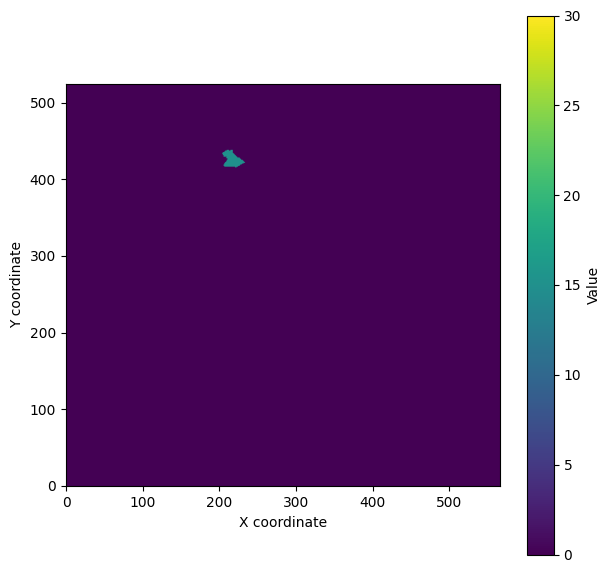

In [ ]:
# ------------------------------
# For visualisation and output
# ------------------------------
# Setup once outside loop
from IPython.display import display, clear_output
import matplotlib.pyplot as plt # NOTE: Ensure matplotlib is imported

fig, ax = plt.subplots(figsize=(7, 7))
# We initialize img with a placeholder array (h must be defined outside the function)
# The colorbar label will be set dynamically inside the function
img = ax.imshow(h, cmap='viridis', origin='lower', vmin=0, vmax=30)
plt.colorbar(img, ax=ax, label='Value') # Changed label to generic 'Value'
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
# plt.close(fig) # <-- KEEP THIS COMMENTED OUT FOR LIVE PLOTTING!
last_output_time = [-1.0]

# IMPORTANT: Ensure the os and numpy libraries are imported where they are needed
# import os
# import numpy as np

In [ ]:
def plot_and_output(step, t, data_array, fig, ax, img,
                    output_interval,
                    vmax,
                    save_output,
                    output_dir,
                    save_format,
                    output_mode,
                    last_output_time,
                    data_label="data"): #
    """
    Plots and optionally saves output every `output_interval` steps or seconds.
    The 'data_label' is used for filenames and plot labels.
    """

    trigger_output = False

    # ... (Trigger logic remains the same) ...
    if output_mode == "step":
        if step % output_interval == 0:
            trigger_output = True
    elif output_mode == "time":
        if int(t // output_interval) > int(last_output_time[0] // output_interval):
            trigger_output = True
            last_output_time[0] = t
    else:
        raise ValueError("output_mode must be either 'step' or 'time'")

    if not trigger_output:
        return

    # --- Update plot ---
    # Use data_array instead of hardcoded h
    img.set_data(data_array)
    img.set_clim(0, vmax)
    ax.set_title(f"{data_label.capitalize()} | Step {step}, Time = {t:.2f} s")

    # Update colorbar label dynamically
    cbar = fig.axes[1] # Assumes the colorbar is the second axis
    cbar.set_ylabel(data_label.capitalize().replace("_", " ")) # Set label

    clear_output(wait=True)
    display(fig)
    plt.pause(0.01)

    # --- Save output ---
    if save_output:
        os.makedirs(output_dir, exist_ok=True)
        if output_mode == "step":
            suffix = f"{step:04d}"
        else:  # time
            suffix = f"t{t:05.1f}"

        # --- FILENAME NOW USES data_label ---
        if save_format == "csv":
            filename = os.path.join(output_dir, f"{data_label}_{suffix}.csv") # <-- FIXED HERE
            np.savetxt(filename, data_array, delimiter=",", fmt="%.4f")
        elif save_format == "png":
            filename = os.path.join(output_dir, f"{data_label}_{suffix}.png") # <-- FIXED HERE
            fig.savefig(filename)

In [ ]:
"""import gspread
from google.auth import default
from google.colab import auth
import numpy as np

# Authentication
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

SHEET_NAME = 'Debris_Flow_ML_Data'
# Connect or Create Sheet
try:
    sh = gc.open(SHEET_NAME)
    worksheet = sh.get_worksheet(0)
    print(f"✅ Connected to: {SHEET_NAME}")

    # NEW CHECK: Only add headers if the sheet is empty
    if not worksheet.get('A1'):
        headers = [
            "cohesion", "delta_bed", "tau_crit_eros", "k_eros", "k_depos", "tau_crit_depos",
            "viscosity", "saturation_factor", "step_n", "time_sec", "max_h",
            "cum_eros_vol", "cum_depos_vol", "current_dist_km"
        ]
        worksheet.append_row(headers)
        print("✨ Added headers to existing empty sheet.")

except gspread.SpreadsheetNotFound:
    sh = gc.create(SHEET_NAME)
    worksheet = sh.get_worksheet(0)
    headers = ["cohesion", "delta_bed", "tau_crit_eros", "k_eros", "k_depos", "tau_crit_depos",
               "viscosity", "saturation_factor", "step_n", "time_sec", "max_h",
               "cum_eros_vol", "cum_depos_vol", "current_dist_km"]
    worksheet.append_row(headers)
    print(f"✨ Created NEW sheet with Time-Series headers.")"""


'import gspread\nfrom google.auth import default\nfrom google.colab import auth\nimport numpy as np\n\n# Authentication\nauth.authenticate_user()\ncreds, _ = default()\ngc = gspread.authorize(creds)\n\nSHEET_NAME = \'Debris_Flow_ML_Data\'\n# Connect or Create Sheet\ntry:\n    sh = gc.open(SHEET_NAME)\n    worksheet = sh.get_worksheet(0)\n    print(f"✅ Connected to: {SHEET_NAME}")\n\n    # NEW CHECK: Only add headers if the sheet is empty\n    if not worksheet.get(\'A1\'):\n        headers = [\n            "cohesion", "delta_bed", "tau_crit_eros", "k_eros", "k_depos", "tau_crit_depos",\n            "viscosity", "saturation_factor", "step_n", "time_sec", "max_h",\n            "cum_eros_vol", "cum_depos_vol", "current_dist_km"\n        ]\n        worksheet.append_row(headers)\n        print("✨ Added headers to existing empty sheet.")\n\nexcept gspread.SpreadsheetNotFound:\n    sh = gc.create(SHEET_NAME)\n    worksheet = sh.get_worksheet(0)\n    headers = ["cohesion", "delta_bed", "tau_cri

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

def run_simulation(cohesion, delta_bed, tau_crit_eros, k_eros, k_depos, bank_factor,
                   saturation_factor, tau_crit_depos, coef_u2_val, viscosity, d_avg, rho, rho_solid):

        # --- Load Data ---
    h = np.asarray(np.loadtxt(thickness_file, delimiter=","))
    z = np.asarray(np.loadtxt(dem_file, delimiter=","))
    e_bed = np.asarray(np.loadtxt(e_bed_file, delimiter=","))

    # Find the initial front before starting the loop
    initial_indices = np.where(h > 0.1)
    if initial_indices[0].size > 0:
        prev_front_y = np.max(initial_indices[0]) * dy
        prev_front_x = np.max(initial_indices[1]) * dx
    else:
        prev_front_y, prev_front_x = 0.0, 0.0


    runout_dist = 0.0
    history = []



    # Initialize the plot window
    plt.ion()
    fig, ax = plt.subplots(figsize=(6, 4))
    # Use 'magma' or 'viridis' to see the flow clearly against a dark background
    im = ax.imshow(h, cmap='magma', origin='lower', extent=[0, ncol*dx, 0, nrow*dy])
    plt.colorbar(im, label="Thickness (m)")
    plt.draw()


    init_vol = np.sum(h[h > 0.1]) * dx * dy
    print("\n" + "="*40)
    print(f"📊 INITIAL STATE SUMMARY")
    print(f"  > Initial Flow Volume: {init_vol:,.2f} m³")
    print(f"  > Grid Resolution: {dx}x{dy} m")
    print("="*40)



    # --- Parameters ---
    h = np.clip(h, 0, 40)
    hfluxmin = 0.01
    max_bed_depth = 15
    g = 9.81
    stop_threshold = 0.05 # Adjust based on your needs
    upper_eros_limit = 6e6
    rain_intensity = 150.0
    max_rain = 200.0

    # --- Pre-allocation ---
    u_xx, u_xy = np.zeros((nrow, ncol-1)), np.zeros((nrow, ncol-1))
    u_yy, u_yx = np.zeros((nrow-1, ncol)), np.zeros((nrow-1, ncol))
    u3_xx, u3_xy = np.zeros_like(u_xx), np.zeros_like(u_xy)
    u3_yx, u3_yy = np.zeros((nrow-1, ncol)), np.zeros((nrow-1, ncol))
    umx, umy = np.zeros_like(h), np.zeros_like(h)
    hmx, hmy = np.zeros((nrow, ncol - 1)), np.zeros((nrow - 1, ncol))
    dirxh, gradxh = np.zeros((nrow, ncol - 1)), np.zeros((nrow, ncol - 1))
    diryh, gradyh = np.zeros((nrow - 1, ncol)), np.zeros((nrow - 1, ncol))
    flux_hx = np.zeros((nrow, ncol + 1))
    flux_huxx, flux_huxy = np.zeros_like(flux_hx), np.zeros_like(flux_hx)
    flux_hy = np.zeros((nrow + 1, ncol))
    flux_huyy, flux_huyx = np.zeros_like(flux_hy), np.zeros_like(flux_hy)

    # --- Physics Constants ---
    coef_C = cohesion / rho
    delta_bed_rad = np.radians(max(delta_bed, 2))
    coef_u = 3 * viscosity / rho
    coef_u2 = np.full_like(z, max(coef_u2_val, 0.001))
    # Rainfall adjusted erosion threshold
    tau_crit_eff = np.maximum(tau_crit_eros * (1 - saturation_factor * (rain_intensity / max_rain)), 0.001)

    # Initial Geometry
    dirxz, diryz, slopexz, slopeyz = compute_interface_slope_features(z, dx, dy)
    dx_x, dy_x, dy_y, dx_y, S = correct_cell_edge_features(z, dx, dy)
    Cxx, Cxy, Cyy, Cyx = compute_slope_curvature(z, dx, dy, dx_x, dy_y)

    t, dt = 0.0, 0.5
    total_eros_vol, total_depos_vol, total_lateral_vol = 0.0, 0.0, 0.0
    output_tracker = [0.0]

    for step in range(max_steps):
        # 1. Surface & Velocity
        compute_flow_surface_properties(h, dx, dy, dirxh, diryh, gradxh, gradyh, hmx, hmy)
        compute_sources_term_velocity(u_xx, u_xy, u_yy, u_yx, h, hmx, hmy,
                                     slopexz, gradxh, dirxz, dirxh, slopeyz, gradyh, diryz, diryh,
                                     Cxx, Cxy, Cyx, Cyy, u3_xx, u3_xy, u3_yx, u3_yy,
                                     coef_u2, coef_C, coef_u, dt, delta_bed_rad, umx, umy)

        # 2. Fluxes & Advection
        compute_fluxes(u3_xx, u3_xy, u_yy, u_yx, h, umx, umy, dy_x, dx_y,
                       flux_hx, flux_huxx, flux_huxy, flux_hy, flux_huyy, flux_huyx)
        h2, umx_h, umy_h = update_cell_center(h, flux_hx, flux_hy, flux_huxx, flux_huxy,
                                              flux_huyx, flux_huyy, umx, umy, S, dt)
        vit_max, dt, t = simple_upwind_update_advection(h, h2, umx, umy, umx_h, umy_h,
                                                       u3_xx, u3_xy, u3_yx, u3_yy,
                                                       u_xx, u_xy, u_yx, u_yy, dt, t)

        # 3. Enhanced Physics: Shear Stress & Curvature
        # Calculate Sin_Theta (Bed Slope)
        sin_theta = np.zeros_like(h)
        sin_theta[:, 1:-1] = (np.sin(slopexz[:, :-1]) + np.sin(slopexz[:, 1:])) / 2.0
        sin_theta[1:-1, :] += (np.sin(slopeyz[:-1, :]) + np.sin(slopeyz[1:, :])) / 2.0
        sin_theta = np.clip(sin_theta / 2.0, 0, 0.866)

        tau = rho * g * h * sin_theta
        local_v = np.sqrt(umx**2 + umy**2 + 1e-6)

        # Calculate Curvature for Lateral Physics
        curv_avg = np.zeros_like(h)
        curv_avg[:, :-1] += np.abs(Cxx) / 2.0
        curv_avg[:, 1:] += np.abs(Cxx) / 2.0
        curv_avg[:-1, :] += np.abs(Cyy) / 2.0
        curv_avg[1:, :] += np.abs(Cyy) / 2.0
        curv_avg = np.maximum(curv_avg, 1e-3)

        # --- 4. Deposition (Reynolds & Stokes Law) ---
        ws = np.clip(g * (rho_solid - 1000) * d_avg**2 / (18 * (viscosity + 1e-3)), 0.001, 1.0)
        Re = np.clip(rho_solid * local_v * h / np.maximum(viscosity, 1e-3), 1, 1e6)
        depos_factor = 1 / (1 + Re / 2000)

        depos_mask = (tau < tau_crit_depos) & (h > hfluxmin)
        deficit_stress = np.maximum(0, (tau_crit_depos - tau) / (tau_crit_depos + 1e-3))
        curv_factor = 1 + (curv_avg * 100)

        dh_depos = np.zeros_like(h)
        # Rate = Ws * (k_dep * deficit * Re_factor / Velocity)
        depos_rate = ws * (k_depos * deficit_stress * depos_factor / np.maximum(local_v, 0.1))
        dh_depos[depos_mask] = np.minimum(h[depos_mask] - hfluxmin, depos_rate[depos_mask] * dt * curv_factor[depos_mask])

        h -= dh_depos
        z += dh_depos
        e_bed += dh_depos
        total_depos_vol += np.sum(dh_depos) * dx * dy

        # --- 5. Erosion (Vertical & Lateral) ---

        dh_eros = np.zeros_like(h)
        dh_lat = np.zeros_like(h)

        if total_eros_vol < upper_eros_limit:
            # A. Vertical Erosion Calculation
            excess_stress = np.maximum(0, tau - tau_crit_eff)
            eros_mask = (tau > tau_crit_eff) & (e_bed < max_bed_depth) & (local_v > 0.1)
            dh_eros[eros_mask] = np.minimum(k_eros * excess_stress[eros_mask] * local_v[eros_mask] * dt, 0.007)
            dh_eros = np.minimum(dh_eros, max_bed_depth - e_bed)

            # B. Lateral Erosion Calculation
            lat_mask = (curv_avg > 1e-3) & (tau > tau_crit_eff) & (e_bed < max_bed_depth)
            dh_lat[lat_mask] = np.minimum(bank_factor * k_eros * excess_stress[lat_mask] * curv_avg[lat_mask] * dt, 0.007)
            dh_lat = np.minimum(dh_lat, max_bed_depth - e_bed)

            # C. Budget Check (Vertical + Lateral)
            potential_step_vol = (np.sum(dh_eros) + np.sum(dh_lat)) * dx * dy
            remaining_limit = upper_eros_limit - total_eros_vol

            if potential_step_vol > remaining_limit and potential_step_vol > 0:
                scale_factor = remaining_limit / potential_step_vol
                dh_eros *= scale_factor
                dh_lat *= scale_factor

            # D. Apply ALL Erosion ONCE
            total_change = dh_eros + dh_lat
            h += total_change
            e_bed += total_change
            z -= total_change
            total_eros_vol += np.sum(total_change) * dx * dy

        # --- 6. Bank Failure (Neighbor Activation) ---
        fail_i, fail_j = np.where(dh_lat > 0)
        h_transfer_pct = 0.1
        for i, j in zip(fail_i, fail_j):
            # Check East/West neighbors for widening
            for dj in [1, -1]:
                nj = j + dj
                if 0 <= nj < ncol:
                    if h[i, nj] < hfluxmin and e_bed[i, nj] < 0.01:
                        e_bed[i, nj] = max_bed_depth
                        h[i, nj] += h[i, j] * h_transfer_pct

        # --- 7. Metrics & Termination ---
        wet_indices = np.where(h > 0.05)
        if wet_indices[0].size > 0:
            # 1. Get current 2D position (leading edge)
            idx_y, idx_x = np.max(wet_indices[0]), np.max(wet_indices[1])
            curr_y = idx_y * dy
            curr_x = idx_x * dx

            # 2. Convert previous physical coordinates back to safe integer indices
            # Using round() + int() is safer than just int() for coordinates
            prev_idx_y = int(round(prev_front_y / dy))
            prev_idx_x = int(round(prev_front_x / dx))

            # Clip indices to stay within the DEM array dimensions
            prev_idx_y = np.clip(prev_idx_y, 0, nrow - 1)
            prev_idx_x = np.clip(prev_idx_x, 0, ncol - 1)

            # 3. Get elevations from DEM
            curr_z = z[idx_y, idx_x]
            prev_z = z[prev_idx_y, prev_idx_x]

            # 4. 3D Distance Formula (Pythagorean theorem in 3D)
            step_movement = np.sqrt((curr_x - prev_front_x)**2 +
                                    (curr_y - prev_front_y)**2 +
                                    (curr_z - prev_z)**2)

            # 5. Accumulate distance and update previous state
            if step_movement > 0:
                runout_dist += step_movement

            prev_front_x, prev_front_y = curr_x, curr_y

            if step % 10 == 0:
                # This logic forces the function to run for plotting,
                # but only allows saving if it's a multiple of 40.
                is_save_step = (step % 20 == 0)

                plot_and_output(
                    step=step,
                    t=t,
                    data_array=h,
                    fig=fig,
                    ax=ax,
                    img=im,
                    output_interval=10,        # Function will trigger because step % 10 == 0
                    vmax=np.max(h) + 0.5,
                    save_output=is_save_step,  # This will be True ONLY every 40 steps
                    output_dir="sim_results",
                    save_format="csv",
                    output_mode="step",
                    last_output_time=output_tracker,
                    data_label="thickness"
                )

        # Immediate Break if limit reached
        if total_eros_vol >= upper_eros_limit:
            print(f"🛑 Limit of {upper_eros_limit} reached at step {step}")
            break

        if (vit_max <= stop_threshold and step > 100) or np.isnan(vit_max):
            print("🛑 Flow stopped or became unstable. Terminating.")
            break

        if step % 10 == 0:
            print(f"  [START] Initial Vol: {init_vol:.2f} m³")
            print(f"t={t:.2f} | Dist: {runout_dist:.1f}m | Erosion: {total_eros_vol:.1f}m³")
            history.append([step, round(t, 2), float(np.max(h)), round(total_eros_vol, 2),
                            round(total_depos_vol, 2), round(runout_dist / 1000, 3)])


        # Periodic Slope Update
        if step % 20 == 0:
            z = gaussian_filter(z, sigma=0.2)
            dirxz, diryz, slopexz, slopeyz = compute_interface_slope_features(z, dx, dy)
            Cxx, Cxy, Cyy, Cyx = compute_slope_curvature(z, dx, dy, dx_x, dy_y)
    plt.ioff() # Turn off interactive mode when done
    plt.show() # Keep the final frame visible

    return h, total_eros_vol, init_vol, total_depos_vol, runout_dist, history

**RUN SIMULATION**

In [ ]:
"""import random
import time

# --- 1. THE LOGGING FUNCTION ---
def log_run_to_sheets(params, results):
    try:
        # Expected return order: (h, eros, init_vol, depos, dist, history)
        total_eros_vol = results[1]
        total_depos_vol = results[3]
        runout_dist_km = results[4] / 1000
        history = results[5]

        if history:
            last_entry = history[-1]
            # step, time, max_h, volume, dist
            step_n, time_sec, max_h = last_entry[0], last_entry[1], last_entry[2]
        else:
            step_n, time_sec, max_h = 0, 0, 0

        row = [
            params["cohesion"], params["delta_bed"], params["tau_crit_eros"],
            params["k_eros"], params["k_depos"], params["tau_crit_depos"],
            params.get("viscosity", 0.01), params.get("saturation_factor", 0.9),
            step_n, time_sec, max_h, total_eros_vol, total_depos_vol, runout_dist_km
        ]

        worksheet.append_row(row)
        return True
    except Exception as e:
        print(f"⚠️ Sheet Logging Error: {e}")
        return False"""

'import random\nimport time\n\n# --- 1. THE LOGGING FUNCTION ---\ndef log_run_to_sheets(params, results):\n    try:\n        # Expected return order: (h, eros, init_vol, depos, dist, history)\n        total_eros_vol = results[1]\n        total_depos_vol = results[3]\n        runout_dist_km = results[4] / 1000\n        history = results[5]\n\n        if history:\n            last_entry = history[-1]\n            # step, time, max_h, volume, dist\n            step_n, time_sec, max_h = last_entry[0], last_entry[1], last_entry[2]\n        else:\n            step_n, time_sec, max_h = 0, 0, 0\n\n        row = [\n            params["cohesion"], params["delta_bed"], params["tau_crit_eros"],\n            params["k_eros"], params["k_depos"], params["tau_crit_depos"],\n            params.get("viscosity", 0.01), params.get("saturation_factor", 0.9),\n            step_n, time_sec, max_h, total_eros_vol, total_depos_vol, runout_dist_km\n        ]\n\n        worksheet.append_row(row)\n        return 

In [ ]:
"""
# --- 2. AUTOMATION CONFIGURATION ---

#PUTHUMALA
# Your requested fixed values
FIXED_PARAMS = {
    "delta_bed": 0.0005,  #(5.0, 16.0)
    "coef_u2": 0.001, #(0.001 to 0.005)
    "rho": 2900,
    "saturation_factor": 0.9,
    "bank_factor": 1.5,
    "d_avg": 0.01, #0.01 to 0.05
    "tau_crit_eros": 500,
    "k_eros": 0.000001,
    "k_depos": 600,
    "tau_crit_depos": 650,
    "cohesion": 200,
    "rho_solid": 1800,
    "viscosity":0.0002
}"""

'\n# --- 2. AUTOMATION CONFIGURATION ---\n\n#PUTHUMALA\n# Your requested fixed values\nFIXED_PARAMS = {\n    "delta_bed": 0.0005,  #(5.0, 16.0)\n    "coef_u2": 0.001, #(0.001 to 0.005)\n    "rho": 2900,\n    "saturation_factor": 0.9,\n    "bank_factor": 1.5,\n    "d_avg": 0.01, #0.01 to 0.05\n    "tau_crit_eros": 500,\n    "k_eros": 0.000001,\n    "k_depos": 600,\n    "tau_crit_depos": 650,\n    "cohesion": 200,\n    "rho_solid": 1800,\n    "viscosity":0.0002\n}'

In [ ]:


# --- 2. AUTOMATION CONFIGURATION ---

#CHOORALMALA
# Your requested fixed values
FIXED_PARAMS = {
    "delta_bed": 0.05,  #(5.0, 16.0)
    "coef_u2": 0.001, #(0.001 to 0.005)
    "rho": 2900,
    "saturation_factor": 0.9,
    "bank_factor": 1.5,
    "d_avg": 0.01, #0.01 to 0.05
    "tau_crit_eros": 500,
    "k_eros": 0.000001,
    "k_depos": 600,
    "tau_crit_depos": 650,
    "cohesion": 1000,
    "rho_solid": 1800,
    "viscosity":0.002
}

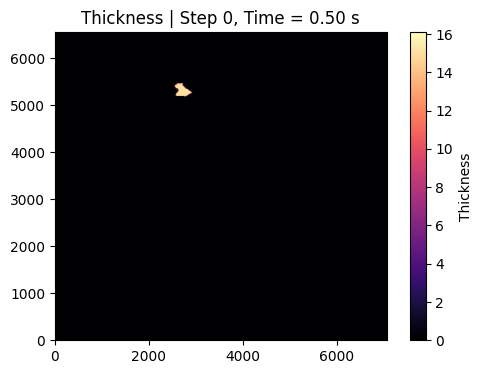

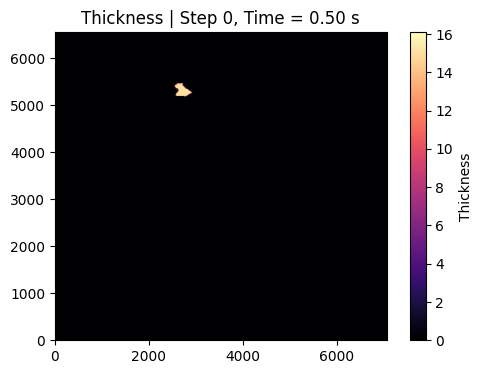

  [START] Initial Vol: 912600.58 m³
t=0.50 | Dist: 25.7m | Erosion: 525.1m³
Max u3_xx: 9.1209, Max u3_xy: 8.7685
Max u3_yx: 7.5096, Max u3_yy: 10.3568
Max u3_xx: 10.6573, Max u3_xy: 11.5447
Max u3_yx: 9.9969, Max u3_yy: 12.3015
Max u3_xx: 12.6363, Max u3_xy: 14.2793
Max u3_yx: 12.2426, Max u3_yy: 14.4365
Max u3_xx: 14.2287, Max u3_xy: 16.4736
Max u3_yx: 13.9620, Max u3_yy: 16.8086


KeyboardInterrupt: 

In [ ]:
# Initialize run_params from your fixed dictionary
run_params = FIXED_PARAMS.copy()

results = run_simulation(
                cohesion=run_params["cohesion"],
                delta_bed=run_params["delta_bed"],
                tau_crit_eros=run_params["tau_crit_eros"],
                k_eros=run_params["k_eros"],
                k_depos=run_params["k_depos"],
                bank_factor=run_params["bank_factor"],
                saturation_factor=run_params["saturation_factor"],
                tau_crit_depos=run_params["tau_crit_depos"],
                coef_u2_val=run_params["coef_u2"],
                viscosity=run_params["viscosity"],
                d_avg=run_params["d_avg"],
                rho=run_params["rho"],
                rho_solid=run_params["rho_solid"]
                )

# Extract metrics for the report
eros_vol = results[1]
dist_km = results[4] / 1000

# Improved reporting format
print(f"Erosion: {eros_vol/1e6:>6.2f}M m³ | Distance: {dist_km:>6.2f} km")

if eros_vol >= 5e6 and dist_km >= 6:
  print("🌟 TARGET CRITERIA MET!")

In [ ]:
"""log_run_to_sheets(run_params, results)"""


In [ ]:
"""baseline = {
    "rho_solid": 1800
}

ranges = {

    "viscosity": np.linspace(0.002, 0.005, 10)
}


print(f"🚀 Starting Symmetrical Sensitivity Analysis...")
print(f"Total planned runs: {len(ranges) * 5}")
for param_name, test_values in ranges.items():
    print(f"\n" + "="*5)
    print(f"📈 SENSITIVITY CATEGORY: {param_name}")
    print("="*5)

    for val in test_values:
        run_params = {**FIXED_PARAMS, **baseline}
        run_params[param_name] = round(val, 8)

        print(f"\n▶️ RUNNING: {param_name} = {run_params[param_name]}")

        try:
            # 3. Execute Simulation
            print(f"--- 🏁 Starting Simulation for {param_name}: {val} ---")
            results = run_simulation(
                cohesion=run_params["cohesion"],
                delta_bed=run_params["delta_bed"],
                tau_crit_eros=run_params["tau_crit_eros"],
                k_eros=run_params["k_eros"],
                k_depos=run_params["k_depos"],
                bank_factor=run_params["bank_factor"],
                saturation_factor=run_params["saturation_factor"],
                tau_crit_depos=run_params["tau_crit_depos"],
                coef_u2_val=run_params["coef_u2"],
                viscosity=run_params["viscosity"],
                d_avg=run_params["d_avg"],
                rho=run_params["rho"],
                rho_solid=run_params["rho_solid"]
            )

            # Extract metrics for the report
            eros_vol = results[1]
            dist_km = results[4] / 1000

            # 4. Log to Sheet (Only call this ONCE)
            if log_run_to_sheets(run_params, results):
                status = "✅ Saved"
            else:
                status = "❌ Not Saved"

            # Final Report for this specific run
            print(f"{status} | Erosion: {eros_vol/1e6:.2f}M m³ | Distance: {dist_km:.2f} km")

            if eros_vol >= 5e6 and dist_km >= 6:
                print("🌟 TARGET CRITERIA MET!")

        except Exception as e:
            print(f"🛑 Simulation crashed on {param_name}={val}: {e}")
            continue

print("\n✨ Sensitivity analysis complete. Check your Google Drive.")"""

In [ ]:
"""# --- ENTER YOUR NUMBERS HERE ---
params = {
    "cohesion": 1000,           # Pa
    "delta_bed": 0.05,            # degrees
    "tau_crit_eros": 8000,       # Pa
    "k_eros": 0.0001,           # Erosion coefficient
    "k_depos": 0.005,           # Deposition constant
    "bank_factor": 1.5,         # Lateral erosion multiplier
    "saturation_factor": 0.5,   # 0 to 1
    "tau_crit_depos": 0.5,      # Pa
    "coef_u2": 0.0001,            # Damping/Turbulence
    "viscosity": 0.05,           # Pa·s
    "d_avg": 0.002,             # Grain size (meters)
    "rho": 3000,                # Mixture density (kg/m³)
    "rho_solid": 1800           # Solid density (kg/m³)
}"""


# **Convert** csv to tiff

In [ ]:
# Use the '!' prefix to run shell commands in Jupyter/Colab notebooks

print("Installing rasterio and required dependencies...")

# Install numpy and pandas just in case, and rasterio
!pip install rasterio numpy pandas
# Installing or upgrading gdal sometimes fixes common linking issues in Colab environments
!pip install --upgrade gdal

print("Setup complete. You may proceed to run the conversion script.")

SAVE TO ZIP

In [ ]:
import numpy as np
import rasterio
from rasterio.transform import from_origin
import os
from pathlib import Path
from google.colab import files  # NEW: Added for downloading

def convert_csv_to_tif(csv_file_path, output_raster_path, rows, cols, res, xmin, ymax, crs='EPSG:32643'):
    try:
        data = np.genfromtxt(csv_file_path, delimiter=",", filling_values=np.nan)

        if data.shape[0] != rows or data.shape[1] != cols:
            print(f"Warning: {os.path.basename(csv_file_path)} shape {data.shape} mismatch. Padding to ({rows}, {cols}).")
            padded_data = np.full((rows, cols), np.nan, dtype=data.dtype)
            padded_data[:min(rows, data.shape[0]), :min(cols, data.shape[1])] = data[:min(rows, data.shape[0]), :min(cols, data.shape[1])]
            data = padded_data

        transform = from_origin(xmin, ymax, res, res)

        profile = {
            'driver': 'GTiff',
            'height': rows,
            'width': cols,
            'count': 1,
            'dtype': rasterio.float32,
            'crs': crs,
            'transform': transform,
            'nodata': np.nan
        }

        with rasterio.open(output_raster_path, 'w', **profile) as dst:
            dst.write(data.astype(rasterio.float32), 1)

        print(f"Done: {os.path.basename(output_raster_path)}")

    except Exception as e:
        print(f"Error converting {csv_file_path}: {e}")

def batch_convert_folder(input_folder, output_folder, rows, cols, res, xmin, ymax, crs='EPSG:32643'):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created output directory: {output_folder}")

    files_list = [f for f in os.listdir(input_folder) if f.endswith('.csv')]

    if not files_list:
        print("No CSV files found in the input folder.")
        return

    print(f"Found {len(files_list)} files. Starting conversion...")

    for filename in files_list:
        input_path = os.path.join(input_folder, filename)
        output_name = filename.replace('.csv', '.tif')
        output_path = os.path.join(output_folder, output_name)
        convert_csv_to_tif(input_path, output_path, rows, cols, res, xmin, ymax, crs)

# --- CONFIGURATION ---
input_dir = "/content/sim_results"
output_dir = "/content/output_tif2/"

#CHOORALA Use the parameters for the specific site (e.g., choralmala)
batch_convert_folder(
    input_folder=input_dir,
    output_folder=output_dir,
    rows=525,
    cols=566,
    res=12.49,
    xmin=621216,
    ymax=1273106,
    crs='EPSG:32643'
)


# --- NEW: DOWNLOAD SECTION ---
print("\nPreparing for download...")
import shutil

# 1. Zip the output folder
zip_name = "Chooralmala_Results2"
shutil.make_archive(zip_name, 'zip', output_dir)

# 2. Trigger the browser download
files.download(f"{zip_name}.zip")
print(f"Download of {zip_name}.zip triggered!")

ONLY CONVERT

In [ ]:
"""import numpy as np
import rasterio
from rasterio.transform import from_origin
import os
from pathlib import Path

def convert_csv_to_tif(csv_file_path, output_raster_path, rows, cols, res, xmin, ymax, crs='EPSG:32643'):
    """
    Converts a single CSV file to a GeoTIFF.
    """
    try:
        data = np.genfromtxt(csv_file_path, delimiter=",", filling_values=np.nan)

        if data.shape[0] != rows or data.shape[1] != cols:
            print(f"Warning: {os.path.basename(csv_file_path)} shape {data.shape} mismatch. Padding to ({rows}, {cols}).")
            padded_data = np.full((rows, cols), np.nan, dtype=data.dtype)
            padded_data[:min(rows, data.shape[0]), :min(cols, data.shape[1])] = data[:min(rows, data.shape[0]), :min(cols, data.shape[1])]
            data = padded_data

        transform = from_origin(xmin, ymax, res, res)

        profile = {
            'driver': 'GTiff',
            'height': rows,
            'width': cols,
            'count': 1,
            'dtype': rasterio.float32,
            'crs': crs,
            'transform': transform,
            'nodata': np.nan
        }

        with rasterio.open(output_raster_path, 'w', **profile) as dst:
            dst.write(data.astype(rasterio.float32), 1)

        print(f"Done: {os.path.basename(output_raster_path)}")

    except Exception as e:
        print(f"Error converting {csv_file_path}: {e}")

def batch_convert_folder(input_folder, output_folder, rows, cols, res, xmin, ymax, crs='EPSG:32643'):
    """
    Finds all CSVs in a folder and converts them using the same configuration.
    """
    # Create output directory if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created output directory: {output_folder}")

    # List all files and filter for .csv
    files = [f for f in os.listdir(input_folder) if f.endswith('.csv')]

    if not files:
        print("No CSV files found in the input folder.")
        return

    print(f"Found {len(files)} files. Starting conversion...")

    for filename in files:
        input_path = os.path.join(input_folder, filename)
        # Create output name by changing extension to .tif
        output_name = filename.replace('.csv', '.tif')
        output_path = os.path.join(output_folder, output_name)

        convert_csv_to_tif(input_path, output_path, rows, cols, res, xmin, ymax, crs)

# --- CONFIGURATION ---
# Set your paths here
input_dir = "/content/sim_results"  # Folder containing your CSVs
output_dir = "/content/output_tif3/" # Where you want the TIFs to go

"""#CHOORALA Use the parameters for the specific site (e.g., choralmala)
batch_convert_folder(
    input_folder=input_dir,
    output_folder=output_dir,
    rows=525,
    cols=566,
    res=12.49,
    xmin=621216,
    ymax=1273106,
    crs='EPSG:32643'
)"""

# Use the parameters for the specific site (e.g., choralmala)
batch_convert_folder(
    input_folder=input_dir,
    output_folder=output_dir,
    rows=508,
    cols=623,
    res=12.49,
    xmin=620860,
    ymax=1275697,
    crs='EPSG:32643'
)"""

COMBINE ALL RASTERS

In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def get_overlap_heatmap(input_folder, output_file):
    tif_files = [os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.endswith('.tif')]

    if not tif_files:
        print("No files found.")
        return

    with rasterio.open(tif_files[0]) as src:
        meta = src.meta.copy()
        # Use int16 to avoid overflow if you have many files
        accumulator = np.zeros((meta['height'], meta['width']), dtype=np.int16)

    for f in tif_files:
        with rasterio.open(f) as src:
            data = src.read(1)
            # Add 1 where data is NOT NaN and NOT 0 (if 0 is your background)
            mask = (~np.isnan(data)) & (data != 0)
            accumulator += mask.astype(np.int16)

    # Save the count map
    meta.update(dtype=rasterio.int16, count=1, nodata=-1)
    with rasterio.open(output_file, 'w', **meta) as dst:
        dst.write(accumulator, 1)

    return accumulator

# Run it
counts = get_overlap_heatmap("/content/output_tifs2", "/content/overlap_counts.tif")

# Plot it specifically for Colab
plt.figure(figsize=(12, 8))
plt.imshow(counts, cmap='viridis') # Viridis is great for showing density
plt.colorbar(label='Number of overlapping rasters')
plt.title("Overlap Intensity Map")
plt.show()

# Visualize grids CSVs

visulaize csv

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_grid_array(data_array, title):
    """
    Displays a NumPy array containing grid data (like h, e_bed, or a mask) as a heatmap.

    Args:
        data_array (np.ndarray): The 2D NumPy array to plot.
        title (str): The title for the plot.
    """
    if not isinstance(data_array, np.ndarray) or data_array.ndim != 2:
        print(f"Error: Input must be a 2D NumPy array. Received type: {type(data_array)}")
        return

    try:
        plt.figure(figsize=(10, 6))

        # Use 'Greys' cmap for binary masks, or 'viridis' for continuous data
        cmap = 'Greys' if np.all(np.isin(data_array, [0, 1])) else 'viridis'

        # Display the matrix as a heatmap
        img = plt.imshow(data_array, cmap=cmap, origin='lower')

        # Add a color bar
        # Only add if the data is not a simple binary mask (or if we need to see the values)
        if cmap != 'Greys' or np.max(data_array) > 1:
            plt.colorbar(img, label='Value Magnitude')

        # Add titles and labels
        plt.title(title)
        plt.xlabel('Grid Column Index (X)')
        plt.ylabel('Grid Row Index (Y)')

        plt.show()

        # Print stats
        print(f"\n--- {title} Statistics ---")
        print(f"Shape (Rows x Columns): {data_array.shape}")
        print(f"Maximum Value: {np.max(data_array):.4f}")
        print(f"Mean Value (non-zero): {np.mean(data_array[data_array > 0]):.4f}")
        print(f"Sum (Active Cells): {np.sum(data_array):.0f}")
        print("----------------------------\n")

    except Exception as e:
        print(f"An error occurred while plotting the array: {e}")

# ===================================================================
# 💻 USAGE EXAMPLE (within your simulation code):
# ===================================================================

# Assuming you have computed the following arrays inside your simulation loop:
# eros_mask: a boolean mask (True/False)
# e_bed: the erodible bed depth array (np.ndarray)
# h: the flow depth array (np.ndarray)

# Example to visualize the erosion mask:
# visualize_grid_array(eros_mask.astype(float), 'Active Erosion Mask')

# Example to visualize the current erodible bed:
visualize_grid_array(df, 'Current Elev')

# *2D PLOT* THE OUTPUT ON TRUE EXTENT

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def compare_simulation_to_true_extent(simulation_data, true_extent_data, title='Simulation vs. True Extent'):
    """
    Displays a simulation output heatmap and OVERLAYS a transparent true extent mask
    with a higher z-order to ensure it appears on top.

    Args:
        simulation_data (np.ndarray): The 2D NumPy array of the simulation output (e.g., flow depth).
        true_extent_data (np.ndarray): The 2D NumPy array of the binary true extent mask.
        title (str): The title for the plot.
    """
    if not isinstance(simulation_data, np.ndarray) or simulation_data.ndim != 2:
        print(f"Error: Simulation data must be a 2D NumPy array. Received type: {type(simulation_data)}")
        return
    if not isinstance(true_extent_data, np.ndarray) or true_extent_data.ndim != 2:
        print(f"Error: True extent data must be a 2D NumPy array. Received type: {type(true_extent_data)}")
        return

    try:
        plt.figure(figsize=(10, 8))

        # 1. Plot the Simulation Data (Base Layer)
        # Give it a low zorder to ensure it is at the back
        cmap2 = 'Greys' if np.all(np.isin(simulation_data, [0, 1])) else 'viridis'

        img_sim = plt.imshow(simulation_data, cmap2, origin='lower', zorder=1)

        # Add a color bar for the simulation data
        plt.colorbar(img_sim, label='Simulation Value (e.g., elevation)', fraction=0.046, pad=0.04)

        # 2. Plot the True Extent Data (Overlay)

        # Create a masked array: only show values where the extent is True (> 0 or = 1)
        #true_extent_mask = np.ma.masked_where(true_extent_data == 0, true_extent_data)

        # Plot the mask:
        # - cmap='Reds' (can change to 'Reds', 'Greens', or 'YlOrRd' for better contrast)
        # - alpha=0.2 (Increased transparency to make the base visible, but still visible)
        # - zorder=10 (Set a high z-order to ensure it is drawn ON TOP)
        #plt.imshow(true_extent_mask, cmap='YlOrRd', alpha=0.6, origin='lower', zorder=10)

        # Add titles and labels
        plt.title(title)
        plt.xlabel('Grid Column Index (X)')
        plt.ylabel('Grid Row Index (Y)')

        plt.show()

    except Exception as e:
        print(f"An error occurred while plotting the arrays: {e}")

# --- Execution Logic (Same as before, using placeholder file names) ---
simulation_file = "/content/sim_results/thickness_2320.csv"
true_extent_file = "/content/debris_flow_bounds_c.csv"

try:
    # Load both CSV files
    sim_data = np.loadtxt(simulation_file, delimiter=',')
    extent_data = np.loadtxt(true_extent_file, delimiter=',')

    # Run the comparison plot with the corrected zorder
    compare_simulation_to_true_extent(sim_data, extent_data, 'Debris Flow Simulation')



# SAVING 3D FLOW VIDEO

In [ ]:
# Import the original function for the actual plotting logi
#plot 1 scene to adjust

!sudo apt update
!sudo apt install ffmpeg

!ls -F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import os
import glob
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource # <-- FIX FOR LightSource ERROR
from mpl_toolkits.mplot3d.art3d import Poly3DCollection




# --- ⚙️ CONFIGURATION & ZOOM ---
DATA_DIR = "output_h"
DEM_FILE_PATH = "/content/dem_chooralmala_new.csv"
dx, dy = 12.49, 12.49
H_MAX_GLOBAL = 40.0
H_FLOW_MIN = 0.1

# Zoom in coordinates (Adjusted for better flow visibility based on the image)
X_MIN_PLOT, X_MAX_PLOT = 500, 6000
Y_MIN_PLOT, Y_MAX_PLOT = 0, 5000 # ⬆️ ADJUSTED: Increased Y_MAX_PLOT to capture more of the flow
# --- ------------------------ ---

# --- Load DEM and define global variables ---
Z_DEM_STATIC = np.loadtxt(DEM_FILE_PATH, delimiter=",")
nrow, ncol = Z_DEM_STATIC.shape
x_coords = np.arange(0, ncol * dx, dx)
y_coords = np.arange(0, nrow * dy, dy)
X, Y = np.meshgrid(x_coords, y_coords)

Z_MIN_GLOBAL = np.min(Z_DEM_STATIC)
Z_MAX_GLOBAL = np.max(Z_DEM_STATIC)

if not os.path.exists("animation_frames_static_dem_refined"):
    os.makedirs("animation_frames_static_dem_refined")
# --- 2. TEMPORARY FUNCTION: Load or Create Flow Data (h) ---
def load_sample_h_data():
    """Loads the first 'flow_depth_t*.csv' file or generates a placeholder."""

    # ➒ FIX 1: Search for the correct filename pattern
    h_files = sorted(glob.glob(os.path.join(DATA_DIR, 'flow_depth_t*.csv')))

    if h_files:
        sample_file = h_files[300]
        h_data = np.loadtxt(sample_file, delimiter=",")

        # ➒ FIX 2: Correctly extract time step from the new filename format
        # Example: 'flow_depth_t001.5.csv' -> '001.5' -> 1.5
        filename_base = os.path.basename(sample_file)
        time_part = filename_base.split('_t')[1].replace('.csv', '')
        time_step = float(time_part)

        if h_data.shape != Z_DEM_STATIC.shape:
            raise ValueError(f"Flow data shape {h_data.shape} mismatch with DEM shape {Z_DEM_STATIC.shape}")

        print(f"Loaded flow data from: {os.path.basename(sample_file)}")
        print(f"File time step: t = {time_step:.1f} s")
        return h_data, time_step
    else:
        # Placeholder (Gaussian hill) logic remains for when no files are found
        h_placeholder = 15 * np.exp(-((X - X.mean())**2 + (Y - Y.mean())**2) / (2 * (50000**2)))
        print(f"❌ WARNING: No flow files found in '{DATA_DIR}'. Using placeholder data (Max h: {h_placeholder.max():.1f}m).")
        return h_placeholder, 0.0


  # --- 3. THE ORIGINAL PLOTTING FUNCTION (MODIFIED) ---
def plot_single_surface(h_data, time_step):
    """
    Generates a 3D plot of the flow surface (Z_DEM_STATIC + h)
    with a zoomed-in view, no grid lines, and a dark blue flow color.
    """

    # ➡️ CRITICAL FIX: Add a tiny Z-offset to lift the flow surface above the DEM.
    FLOW_OFFSET = 1e-4 # 0.1 millimeter offset to prevent Z-fighting.

    Z_surface_PLOT = Z_DEM_STATIC + h_data + FLOW_OFFSET # <--- APPLY OFFSET

    mask = h_data < H_FLOW_MIN

    C = np.clip(h_data, H_FLOW_MIN, H_MAX_GLOBAL) # C still based on h_data (not offset)


    fig = plt.figure(figsize=(8, 6)) # ⬆️ ADJUSTED: Increased figure size for better visibility
    ax = fig.add_subplot(111, projection='3d')

    # --- ➒ VIEWING ANGLE AND GRID ADJUSTMENTS ➒ ---
    ax.view_init(elev=30, azim=-65) # ⬆️ ADJUSTED: Changed azim from -80 to -65 for a slightly more direct view
    ax.autoscale_view(tight=True)
    ax.grid(False) # Removed major grid lines

    # --- ➒ ZOOM IN (Set X and Y limits) ➒ ---
    ax.set_xlim(X_MIN_PLOT, X_MAX_PLOT)
    ax.set_ylim(Y_MIN_PLOT, Y_MAX_PLOT)

    # --- ENHANCED LIGHTING SETUP ---
    ls = LightSource(azdeg=225, altdeg=45) # Light from top-left-back for dramatic effect

    # 3. Plot the Static DEM (Terrain)
    ax.plot_surface(X, Y, Z_DEM_STATIC,
                    facecolors=ls.shade(Z_DEM_STATIC, cmap=cm.terrain, vert_exag=0.5, blend_mode='soft'),
                    alpha=0.98,
                    linewidth=0.0,
                    edgecolor='none',
                    antialiased=False,
                    rcount=200, ccount=200,# ⬇️ ADJUSTED: Reduced count for FASTER plotting
                    shade=False)


    FLOW_COLORMAP = plt.colormaps.get_cmap('Blues_r')
    # Calculate the RGB colors based on C, respecting the Z_surface_masked nan values
    colors_rgb = FLOW_COLORMAP(C / H_MAX_GLOBAL)
    colors_rgb[mask, 3] = 0.0

    # 4. Plot the Flow Surface using the offsetted Z values
    surf = ax.plot_surface(X, Y, Z_surface_PLOT, # <--- 💡 PLOT THE *FULL* Z_surface_PLOT
                            facecolors=colors_rgb,
                            vmin=H_FLOW_MIN, vmax=H_MAX_GLOBAL,
                            linewidth=0.0,
                            edgecolor='none',
                            antialiased=False,
                            rcount=200, ccount=200, # ⬇️ ADJUSTED: Reduced count for FASTER plotting
                            shade=False)

    # --- Add a subtle base plane to fill the "empty space" below the terrain ---
    zmin_plot = Z_MIN_GLOBAL # or a specific low value
    verts = [list(zip([X_MIN_PLOT, X_MAX_PLOT, X_MAX_PLOT, X_MIN_PLOT],
                      [Y_MIN_PLOT, Y_MIN_PLOT, Y_MAX_PLOT, Y_MAX_PLOT],
                      [zmin_plot, zmin_plot, zmin_plot, zmin_plot]))]
    ax.add_collection3d(Poly3DCollection(verts, alpha=0.1, facecolor='grey', linewidth=0))

    # 5. Labels, Title, and Limits


    ax.set_title(f'Debris Flow Simulation (t = {time_step:.1f} s)', fontsize=20, pad=30)

    # Z-limits remain relative to global DEM min/max

    # Tweak Z-axis formatter to avoid scientific notation if possible



    # Remove the z-axis pane lines for a cleaner look
    ax.xaxis.pane.fill = False

    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')


    # CRITICAL FIX: Ensure the color of the pane itself is transparent/white
    ax.xaxis.pane.set_alpha(0)
    ax.yaxis.pane.set_alpha(0)


    mappable = cm.ScalarMappable(cmap=FLOW_COLORMAP)
    mappable.set_array(C)
    mappable.set_clim(H_FLOW_MIN, H_MAX_GLOBAL)
    cb = fig.colorbar(mappable, ax=ax, shrink=0.7, aspect=20, label='Flow Depth $h$ (m)', pad=0.05)

    cb.set_label('Flow Depth $h$ (m)', fontsize=12, labelpad=15)

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    #plt.show()

# --- 4. EXECUTION ---
if __name__ == '__main__':
    try:
        sample_h_data, sample_time_step = load_sample_h_data()

        # ➡️ DATA CHECK: Validate flow data within the zoomed area
        # Find indices corresponding to the plot limits
        x_indices = np.where((x_coords >= X_MIN_PLOT) & (x_coords <= X_MAX_PLOT))[0]
        y_indices = np.where((y_coords >= Y_MIN_PLOT) & (y_coords <= Y_MAX_PLOT))[0]

        if x_indices.size > 0 and y_indices.size > 0:
            # Slice the flow data to the zoomed area
            h_zoomed = sample_h_data[y_indices.min():y_indices.max()+1, x_indices.min():x_indices.max()+1]
            max_h_zoomed = np.max(h_zoomed)

            if max_h_zoomed < H_FLOW_MIN:
                print(f"⚠️ **WARNING:** Max flow depth in the zoomed area is {max_h_zoomed:.4f}m.")
                print(f"Flow is BELOW the H_FLOW_MIN={H_FLOW_MIN}m threshold, so it will be entirely masked out.")
            else:
                print(f"✅ Flow data FOUND in zoomed area. Max h = {max_h_zoomed:.2f}m.")

        plot_single_surface(sample_h_data, sample_time_step)
        print("Plot window opened. Adjust configuration variables and rerun to view changes.")
    except ValueError as e:
        print(f"Execution Error: {e}")






In [ ]:

DATA_DIR = "output_h"
DEM_FILE_PATH = "/content/dem_chooralmala_new.csv"
dx, dy = 12.49, 12.49
H_MAX_GLOBAL = 40.0
H_FLOW_MIN = 0.1
OUTPUT_FRAMES_DIR = "animation_frames_static_dem_refined"




# Load DEM and define global variables once
Z_DEM_STATIC = np.loadtxt(DEM_FILE_PATH, delimiter=",")
nrow, ncol = Z_DEM_STATIC.shape
x_coords = np.arange(0, ncol * dx, dx)
y_coords = np.arange(0, nrow * dy, dy)
X, Y = np.meshgrid(x_coords, y_coords)

Z_MIN_GLOBAL = np.min(Z_DEM_STATIC)
Z_MAX_GLOBAL = np.max(Z_DEM_STATIC)

if not os.path.exists(OUTPUT_FRAMES_DIR):
    os.makedirs(OUTPUT_FRAMES_DIR)
# --- END GLOBAL SETUP ---


def create_3d_frame_static_dem(h_data, time_step, output_path):
    """
    Generates a 3D plot of the flow surface (Z_DEM_STATIC + h)
    for a single time step and saves it to a file.

    NOTE: Relies on global variables (X, Y, Z_DEM_STATIC, H_MAX_GLOBAL, etc.)
    defined in the setup section above.
    """

    # ➡️ CRITICAL FIX: Add a tiny Z-offset to lift the flow surface above the DEM.
    FLOW_OFFSET = 1e-4

    Z_surface_PLOT = Z_DEM_STATIC + h_data + FLOW_OFFSET
    mask = h_data < H_FLOW_MIN
    C = np.clip(h_data, H_FLOW_MIN, H_MAX_GLOBAL)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # --- VIEWING ANGLE AND AXIS SETUP ---
    ax.view_init(elev=30, azim=-65)
    ax.autoscale_view(tight=True)
    ax.grid(False)

    # --- ZOOM IN (Set X and Y limits) ---
    ax.set_xlim(X_MIN_PLOT, X_MAX_PLOT)
    ax.set_ylim(Y_MIN_PLOT, Y_MAX_PLOT)

    # --- ENHANCED LIGHTING SETUP ---
    ls = LightSource(azdeg=225, altdeg=45)

    # 3. Plot the Static DEM (Terrain)
    ax.plot_surface(X, Y, Z_DEM_STATIC,
                    facecolors=ls.shade(Z_DEM_STATIC, cmap=cm.terrain, vert_exag=0.5, blend_mode='soft'),
                    alpha=0.98, linewidth=0.0, edgecolor='none', antialiased=False,
                    rcount=200, ccount=200, shade=False)

    # 4. Plot the Flow Surface
    FLOW_COLORMAP = plt.colormaps.get_cmap('Blues_r')
    colors_rgb = FLOW_COLORMAP(C / H_MAX_GLOBAL)
    colors_rgb[mask, 3] = 0.0

    ax.plot_surface(X, Y, Z_surface_PLOT,
                    facecolors=colors_rgb,
                    vmin=H_FLOW_MIN, vmax=H_MAX_GLOBAL,
                    linewidth=0.0, edgecolor='none', antialiased=False,
                    rcount=200, ccount=200, shade=False)

    # --- Add a subtle base plane ---
    zmin_plot = Z_MIN_GLOBAL
    verts = [list(zip([X_MIN_PLOT, X_MAX_PLOT, X_MAX_PLOT, X_MIN_PLOT],
                      [Y_MIN_PLOT, Y_MIN_PLOT, Y_MAX_PLOT, Y_MAX_PLOT],
                      [zmin_plot, zmin_plot, zmin_plot, zmin_plot]))]
    ax.add_collection3d(Poly3DCollection(verts, alpha=0.1, facecolor='grey', linewidth=0))

    # 5. Labels and Title
    ax.set_xlabel('Easting (m)', fontsize=14, labelpad=15)
    ax.set_ylabel('Northing (m)', fontsize=14, labelpad=15)
    ax.set_title(f'Debris Flow Simulation (t = {time_step:.1f} s)', fontsize=20, pad=30)

    # Hide Z-axis elements (removed as requested)
    ax.set_yticks([]) # Hide Y-axis tick marks (to clean up residual lines)

    # Remove pane lines (kept for cleanliness)
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('w')
    ax.yaxis.pane.set_edgecolor('w')
    ax.zaxis.pane.set_edgecolor('w')
    ax.xaxis.pane.set_alpha(0)
    ax.yaxis.pane.set_alpha(0)
    ax.zaxis.pane.set_alpha(0)

    # Colorbar
    mappable = cm.ScalarMappable(cmap=FLOW_COLORMAP)
    mappable.set_array(C)
    mappable.set_clim(H_FLOW_MIN, H_MAX_GLOBAL)
    cb = fig.colorbar(mappable, ax=ax, shrink=0.7, aspect=20, label='Flow Depth $h$ (m)', pad=0.05)
    cb.set_label('Flow Depth $h$ (m)', fontsize=12, labelpad=15)

    # Save and Close
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.close(fig)

# 6. Main Execution Loop
def generate_animation_frames_static():
    h_files = sorted(glob.glob(os.path.join(DATA_DIR, 'flow_depth_t*.csv'))) # Added 'flow_depth_t*' pattern check

    if not h_files:
        print(f"❌ Error: No flow_depth_t*.csv files found in '{DATA_DIR}'. Check your DATA_DIR and file naming.")
        return

    print(f"Found {len(h_files)} time steps to process.")

    for i, h_file in enumerate(h_files):
        try:
            filename = os.path.basename(h_file)
            # Robustly extract time step (e.g., handles 'flow_depth_t001.5.csv')
            time_part = filename.split('_t')[1].replace('.csv', '')
            time_step = float(time_part)

            h_data = np.loadtxt(h_file, delimiter=",")

            # Check for shape consistency (optional but good practice)
            if h_data.shape != Z_DEM_STATIC.shape:
                 print(f"⚠️ Skipping {filename}: Shape mismatch.")
                 continue

            frame_output_path = os.path.join(OUTPUT_FRAMES_DIR, f"frame_{i:04d}.png")
            create_3d_frame_static_dem(h_data, time_step, frame_output_path)

            if (i + 1) % 10 == 0 or i == 0 or i == len(h_files) - 1:
                print(f"✅ Generated frame {i+1}/{len(h_files)} for t={time_step:.1f} s")

        except Exception as e:
            print(f"⚠️ Could not process file {h_file}. Error: {e}")

    print("\nAll frames generated successfully. Use FFmpeg to create the final video.")




In [ ]:
# --- 7. Execution Starter ---
if __name__ == '__main__':
  generate_animation_frames_static()

!ffmpeg -framerate 10 -i "animation_frames_static_dem_refined/frame_%04d.png" -c:v libx264 -pix_fmt yuv420p -vf "scale=ceil(iw/2)*2:ceil(ih/2)*2" output_debris_flow_refined.mp4

# SAVE VIDEO OF 2D FLOW

In [ ]:
`import glob
import os

# --- CONFIGURE THESE ---
CSV_DIR = "output_h"  # Make sure this is your PNG directory name!
DATA_LABEL = "flow_depth"
FRAME_DURATION = 1.0      # How long each 20-second frame is displayed in the final video (e.g., 1.0 second)
# -----------------------

# 1. Get all files and sort them chronologically
file_pattern = os.path.join(CSV_DIR, f"{DATA_LABEL}_t*.png")
all_files = glob.glob(file_pattern)

def get_time(filepath):
    # Extracts the time from filename for sorting
    filename = os.path.basename(filepath)
    try:
        time_part = filename.split('_t')[-1].replace('.png', '')
        return float(time_part)
    except ValueError:
        return float('inf')

sorted_files = sorted(all_files, key=get_time)

# 2. Create the FFmpeg input text file with 'duration'
with open('input_list.txt', 'w') as f:
    for filename in sorted_files:
        # Write the file path
        f.write(f"file '{filename}'\n")

        # Write the duration for which this frame should be displayed
        # We write this for ALL files, including the last one
        f.write(f"duration {FRAME_DURATION}\n")

# ... (inside the corrected Python script) ...

# 3. CRUCIAL FIX: The last 'duration' line in the file is NOT processed by FFmpeg.
# We must append the last filename AGAIN so its duration is used.
if sorted_files: # <-- This check is critical
    with open('input_list.txt', 'a') as f:
        f.write(f"file '{sorted_files[-1]}'\n") # <--- ERROR LIKELY HERE if sorted_files is empty

print(f"Created input_list.txt with {len(sorted_files)} frames to process.")
print(f"Last frame time: {get_time(sorted_files[-1]):.1f}s")

In [ ]:
# This command assumes each frame should be shown for 1.0 second in the final video.
# Since your frames are 20s apart, this is 20x speedup.
!ffmpeg -f concat -safe 0 -i input_list.txt -c:v libx264 -t 220 -r 1 -pix_fmt yuv420p debris_flow_slowed.mp4